# **Raport: Lista 3**

## 1. Wybór i opis zbioru danych

1. **`Zbiór: Telco Customer Churn`** pobrany z platformy Kaggle. Klasyczny, bardzo czytelny zbiór podany w "proponowanych zbiorach danych" w liście, spełnia wymogi instrukcji oraz idealnie wpasowuje się w zalecany rozmiar, co pozwala na wiarygodny podział na zbiór treningowy i testowy bez ryzyka przeuczenia "na pamięć". Biznesowy charakter danych (przewidywanie odejścia klienta) sprawia, że tworzenie logicznych reguł decyzyjnych jest intuicyjne.

2. **Opis Zbioru:**
    1. **Zmienna docelowa:**
        *   **Churn** - czy klient zrezygnował z usług w ostatnim miesiącu (`bool`).

    2. **Dane demograficzne klienta:**
        *   **CustomerID** - unikalne ID klienta (`string`).
        *   **Gender** - płeć (`Male / Female- string`).
        *   **SeniorCitizen** - czy klient jest seniorem (`bool`).
        *   **Partner** - czy klient ma partnera (`bool`).
        *   **Dependents** - czy klient ma kogoś na utrzymaniu (`bool`).

    3. **Informacje o koncie i płatnościach:**
        *   **Tenure** - liczba miesięcy klienta w firmie (`int`).
        *   **Contract** - rodzaj zawartej umowy (`string`).
        *   **PaperlessBilling** - czy klient korzysta z faktur elektronicznych (`bool`).
        *   **PaymentMethod** - sposób płatności (`string`).
        *   **MonthlyCharges** - miesięczna kwota abonamentu (`float`).
        *   **TotalCharges** - całkowita kwota zapłacona przez klienta od początku umowy (`float`).

    4. **Posiadane usługi:**
        *   **PhoneService** - czy posiada telefon stacjonarny (`bool`).
        *   **MultipleLines** - czy posiada wiele linii telefonicznych (`string`).
        *   **InternetService** - dostawca internetu (`string`).
        *   **OnlineSecurity** - czy wykupił bezpieczeństwo online (`string`).
        *   **OnlineBackup** - czy posiada kopię zapasową online (`string`).
        *   **DeviceProtection** - czy posiada ubezpieczenie sprzętu (`string`).
        *   **TechSupport** - czy wykupił wsparcie techniczne (`string`).
        *   **StreamingTV / StreamingMovies** - czy korzysta z serwisów streamingowych dostarczanych przez firmę (`string`).

3. **Kluczowe dane w zbiorze:**
    1. **Cechy liczbowe (numeryczne / ciągłe):**
        *   **`MonthlyCharges`**
        *   **`TotalCharges`**
        *   **`tenure`**

    2. **Cechy kategorialne (tekstowe / dyskretne):**
        * **`Contract`**
        * **`OnlineSecurity`**
        * **`InternetService`**
        * **`TechSupport`**
        * **`OnlineBackup`**
        * **`StreamingMovies`**
        * **`StreamingTV`** 
        * **`DeviceProtection`**

In [1]:
# wczytanie potrzebnych bibliotek
import pandas
import matplotlib.pyplot as plt

import sys
sys.path.append('..') # dodanie glownego foldera do projektu

# wczytanie danych i ustawienie precyzji
pandas.set_option("display.precision", 2)
df = pandas.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Preprocessing

In [2]:
from sklearn.model_selection import train_test_split
import src.utils.utils as utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

columns_to_encode = [
	'gender',
	'MultipleLines', 
	'InternetService', 
	'OnlineSecurity', 
	'OnlineBackup',
	'DeviceProtection', 
	'TechSupport', 
	'StreamingTV', 
	'StreamingMovies',
	'Contract', 
	'PaymentMethod'
]
TEST_SIZE = 0.2

# czyszczenie danych i konwersja kolumn
df = df.drop('customerID', axis=1)

utils.map_dtypes_str_to_float(df, 'TotalCharges')
utils.map_dtypes_str_to_float(df, 'MonthlyCharges')
utils.map_dtypes_str_to_bool(df, 'Partner')
utils.map_dtypes_str_to_bool(df, 'Dependents')
utils.map_dtypes_str_to_bool(df, 'PhoneService')
utils.map_dtypes_str_to_bool(df, 'PaperlessBilling')
utils.map_dtypes_str_to_bool(df, 'Churn')

# oddzielenie zmeinnych objasniajacych od docelowej
x = df.drop('Churn', axis=1)
y = df['Churn']

# podzial danych
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=42) # random_state = 42 daje powtarzalność wylosowanych danych

# mapowanie wieloklasowych cech danych kategorialnych
x_train, x_test = utils.apply_one_hot_encoding(x_train, x_test, columns_to_encode)

print(f"Rozmiar całego zbioru: {df.shape[0]}")
print(f"Rozmiar zbioru treningowego: {x_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {x_test.shape[0]}")

Rozmiar całego zbioru: 7043
Rozmiar zbioru treningowego: 5634
Rozmiar zbioru testowego: 1409


### Przygotowanie danych pod regresję

In [3]:
from sklearn.preprocessing import StandardScaler

# usuniecie wierszy gdzie totalCharges jest puste (NaN)
df_reg = df.dropna(subset=['TotalCharges'])

y_reg = df_reg['TotalCharges']

# wyrzucenie silnych powiązanych kolumn z TotalCharges
x_reg = df_reg.drop(['Churn', 'TotalCharges', 'MonthlyCharges'], axis=1)

# podział
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

#one-hot encoding
x_train_reg, x_test_reg = utils.apply_one_hot_encoding(x_train_reg, x_test_reg, columns_to_encode)

#skalowanie danych
scaler_x = StandardScaler()
x_train_scaled = scaler_x.fit_transform(x_train_reg)
x_test_scaled = scaler_x.transform(x_test_reg)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_reg.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_reg.values.reshape(-1, 1)).flatten()

feature_names = x_train_reg.columns
print(f"x_train: {x_train_scaled.shape}")

x_train: (5634, 28)


## 3. Regularyzacja (3.0)

### Regularyzacja L1/L2

Trenowanie własnych modeli Lasso i Ridge


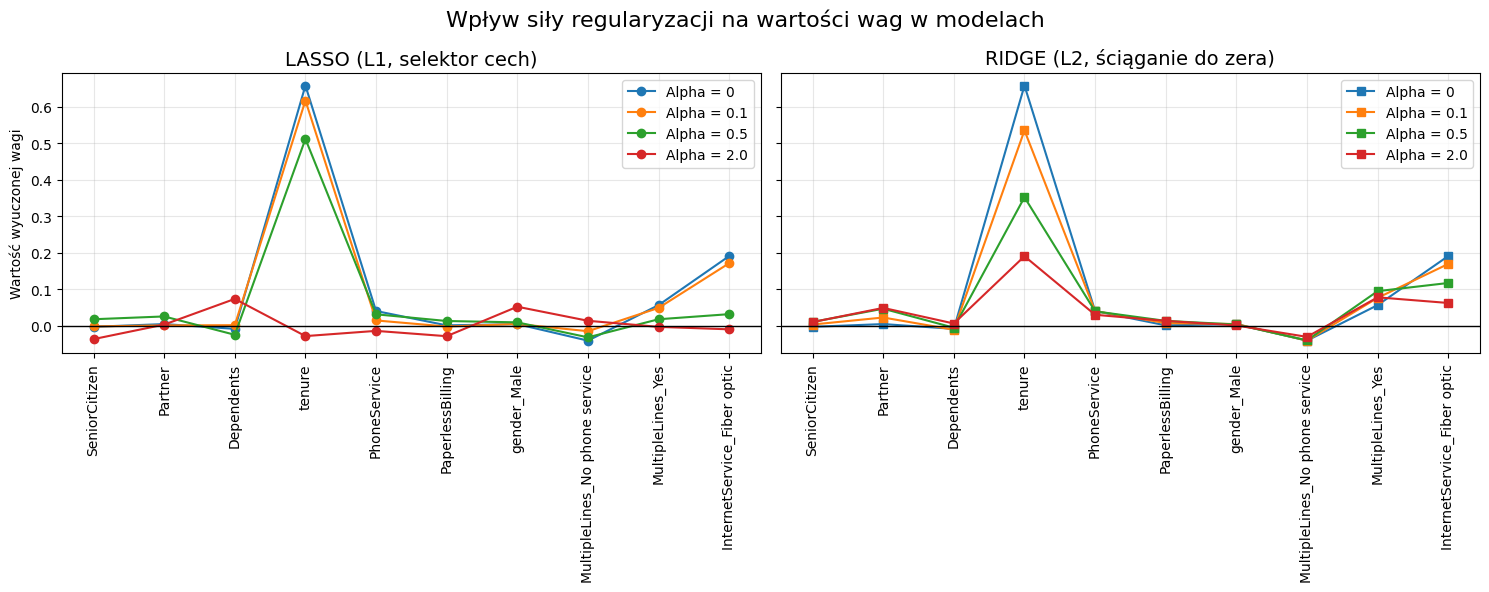

In [4]:
from src.models.LassoRegression import LassoRegression
from src.models.RidgeRegression import RidgeRegression
import matplotlib.pyplot as plt

scaler_y = StandardScaler()
#reshape(-1, 1)- skaler wymaga tablicy 2D
y_train_scaled = scaler_y.fit_transform(y_train_reg.values.reshape(-1, 1)).flatten()

alphas = [0, 0.1, 0.5, 2.0]

weights_lasso = []
weights_ridge = []

print("Trenowanie własnych modeli Lasso i Ridge")
for a in alphas:
    # lasso (L1)
    model_l1 = LassoRegression(alpha=a, learning_rate=0.05, epochs=1500)
    model_l1.fit(x_train_scaled, y_train_scaled)
    weights_lasso.append(model_l1.weights)
    
    # ridge (L2)
    model_l2 = RidgeRegression(alpha=a, learning_rate=0.05, epochs=1500)
    model_l2.fit(x_train_scaled, y_train_scaled)
    weights_ridge.append(model_l2.weights)

# narysowanie wykresu dla czytelnosci (zabrano 10 najwazniejszych cech)
attribs_to_plot = 10
x_indexes = np.arange(attribs_to_plot)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

#wykres lasso
for i, a in enumerate(alphas):
    axes[0].plot(x_indexes, weights_lasso[i][:attribs_to_plot], marker='o', label=f'Alpha = {a}')
axes[0].set_title("LASSO (L1, selektor cech)", fontsize=14)
axes[0].set_ylabel("Wartość wyuczonej wagi")
axes[0].set_xticks(x_indexes)
axes[0].set_xticklabels(feature_names[:attribs_to_plot], rotation=90)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='black', linewidth=1)

#wkres ridge
for i, a in enumerate(alphas):
    axes[1].plot(x_indexes, weights_ridge[i][:attribs_to_plot], marker='s', label=f'Alpha = {a}')
axes[1].set_title("RIDGE (L2, ściąganie do zera)", fontsize=14)
axes[1].set_xticks(x_indexes)
axes[1].set_xticklabels(feature_names[:attribs_to_plot], rotation=90)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='black', linewidth=1)

plt.suptitle("Wpływ siły regularyzacji na wartości wag w modelach", fontsize=16)
plt.tight_layout()
plt.show()

### Wnioski: Analiza działania regularyzacji Lasso L1/L2

1. **Lasso (Regularyzacja L1) jako selektor cech:**
   Wykres po lewej pokazuje, że w miarę zwiększania siły kagańca (`alpha`), algorytm całkowicie **wyzerował wagi** większości badanych cech. Matematyka tej metody (kara w postaci wartości bezwzględnej) zmusza model do stworzenia macierzy "rzadkiej". Lasso uczy się tylko na kilku najistotniejszych kolumnach (tu: `tenure`), wyrzucając szum informacyjny.

2. **Ridge (Regularyzacja L2):**
   Wykres po prawej pokazuje, że kara działa płynniej. Przy wzroście parametru `alpha`, wagi są drastycznie ściągane w stronę zera (co redukuje wariancję i problem przeuczenia), ale **żadna z nich nie zostaje dokładnie wyzerowana**. Algorytm wciąż bierze pod uwagę wszystkie cechy, ale nie pozwala żadnej z nich być bardzo znaczącą.

### Regularyzacja drzew decyzyjnych 

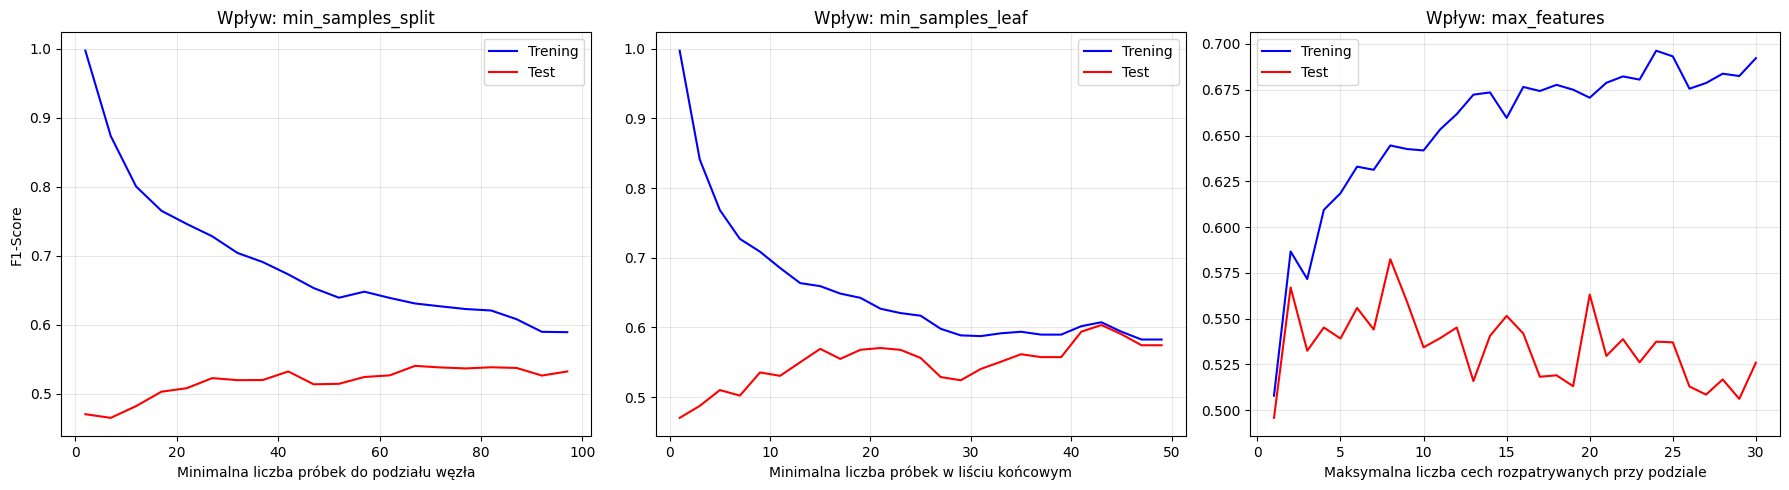

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score


# Definiujemy zakresy do testowania dla każdego parametru
splits_range = range(2, 100, 5)        # min_samples_split
leaves_range = range(1, 50, 2)         # min_samples_leaf
features_range = range(1, x_train.shape[1] + 1) # max_features (od 1 do wszystkich kolumn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# badanie min_samples_split
train_f1_split, test_f1_split = [], []
for s in splits_range:
    tree = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    tree.fit(x_train, y_train)
    train_f1_split.append(f1_score(y_train, tree.predict(x_train)))
    test_f1_split.append(f1_score(y_test, tree.predict(x_test)))

axes[0].plot(splits_range, train_f1_split, label='Trening', color='blue')
axes[0].plot(splits_range, test_f1_split, label='Test', color='red')
axes[0].set_title("Wpływ: min_samples_split")
axes[0].set_xlabel("Minimalna liczba próbek do podziału węzła")
axes[0].set_ylabel("F1-Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#badanie min_samples_leaf
train_f1_leaf, test_f1_leaf = [], []
for l in leaves_range:
    tree = DecisionTreeClassifier(min_samples_leaf=l, random_state=42)
    tree.fit(x_train, y_train)
    train_f1_leaf.append(f1_score(y_train, tree.predict(x_train)))
    test_f1_leaf.append(f1_score(y_test, tree.predict(x_test)))

axes[1].plot(leaves_range, train_f1_leaf, label='Trening', color='blue')
axes[1].plot(leaves_range, test_f1_leaf, label='Test', color='red')
axes[1].set_title("Wpływ: min_samples_leaf")
axes[1].set_xlabel("Minimalna liczba próbek w liściu końcowym")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# badanie max_features
train_f1_feat, test_f1_feat = [], []
for f in features_range:
    # dodanie min_samples_leaf dla stabilnosci drzewa
    tree = DecisionTreeClassifier(max_features=f, min_samples_leaf=10, random_state=42)
    tree.fit(x_train, y_train)
    train_f1_feat.append(f1_score(y_train, tree.predict(x_train)))
    test_f1_feat.append(f1_score(y_test, tree.predict(x_test)))

axes[2].plot(features_range, train_f1_feat, label='Trening', color='blue')
axes[2].plot(features_range, test_f1_feat, label='Test', color='red')
axes[2].set_title("Wpływ: max_features")
axes[2].set_xlabel("Maksymalna liczba cech rozpatrywanych przy podziale")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Wnioski
Wykresy pokazują, jak poszczególne parametry wpływają na ograniczenie zjawiska overfittingu:
1. **`min_samples_split`:** Wraz ze wzrostem wymaganej liczby klientów potrzebnej do podziału, złożoność drzewa maleje. Błąd treningowy spada z idealnego 1.0 w dół, a wynik testowy stabilizuje się, chroniąc przed modelem z głębokimi węzłami.
2. **`min_samples_leaf`:** Wymusza by żadna ostateczna reguła nie dotyczyła liczby klientów mniejszej od podanej. Na wykresie bardzo redukuje rozstrzał pomiędzy zbiorem treningowym a testowym.
3. **`max_features`:** Wymusza na modelu losowanie tylko małego podzbioru cech przy każdym kroku (zamiast szukania zawsze najlepszej kolumny w całym zbiorze). Na lewej stronie wykresu widać, gdy rozpatruje się mało cech, drzewo staje się bardziej losowe, co czasami potrafi lekko poprawić generalizację, choć na tym konkretnym zbiorze efekt jest mniej drastyczny niż przy limitach na próbki w liściu.

### Sweet spot dla zoverfittowanego modelu

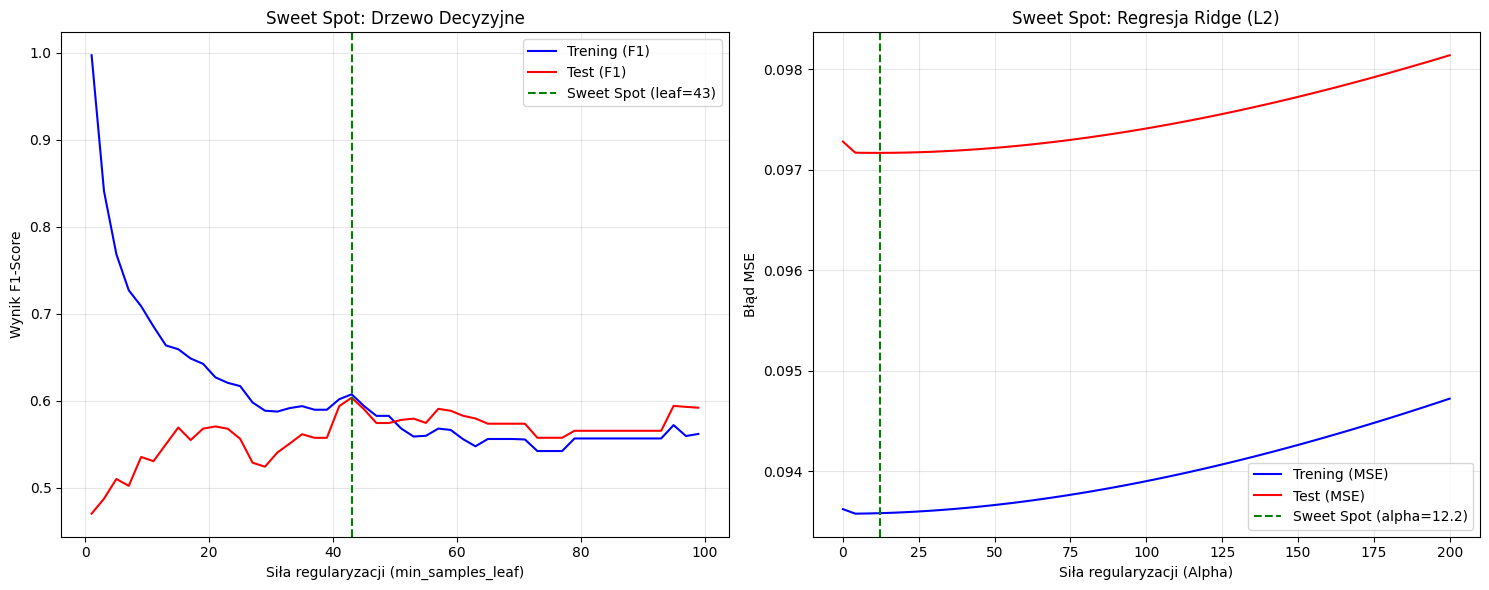

----wyniki modeli ----
Drzewo bazowe (leaf=1) F1-Test:    0.4703
Drzewo sweet spot (leaf=43) F1-Test: 0.6036

Regresja bazowa (alpha=0) MSE-Test: 0.0973
Regresja sweet spot (alpha=12.2) MSE-Test: 0.0972


In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

leaf_values = range(1, 100, 2)
train_scores_tree, test_scores_tree = [], []

# sweet spot dla drzewa
for leaf in leaf_values:
    tree = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    tree.fit(x_train, y_train)
    train_scores_tree.append(f1_score(y_train, tree.predict(x_train)))
    test_scores_tree.append(f1_score(y_test, tree.predict(x_test)))

best_leaf_idx = np.argmax(test_scores_tree)
best_leaf = leaf_values[best_leaf_idx]

axes[0].plot(leaf_values, train_scores_tree, label='Trening (F1)', color='blue')
axes[0].plot(leaf_values, test_scores_tree, label='Test (F1)', color='red')
axes[0].axvline(best_leaf, color='green', linestyle='--', label=f'Sweet Spot (leaf={best_leaf})')
axes[0].set_title("Sweet Spot: Drzewo Decyzyjne")
axes[0].set_xlabel("Siła regularyzacji (min_samples_leaf)")
axes[0].set_ylabel("Wynik F1-Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#sweet spot dla regresji
alphas_range = np.linspace(0.00, 200, 50)
train_mse, test_mse = [], []

for a in alphas_range:
    # ridge zostal uzyty dla ladniejszego wyrkesu
    ridge = Ridge(alpha=a)
    ridge.fit(x_train_scaled, y_train_scaled)
    
    train_mse.append(mean_squared_error(y_train_scaled, ridge.predict(x_train_scaled)))
    test_mse.append(mean_squared_error(y_test_scaled, ridge.predict(x_test_scaled)))

best_alpha_idx = np.argmin(test_mse)
best_alpha = alphas_range[best_alpha_idx]

axes[1].plot(alphas_range, train_mse, label='Trening (MSE)', color='blue')
axes[1].plot(alphas_range, test_mse, label='Test (MSE)', color='red')
axes[1].axvline(best_alpha, color='green', linestyle='--', label=f'Sweet Spot (alpha={best_alpha:.1f})')
axes[1].set_title("Sweet Spot: Regresja Ridge (L2)")
axes[1].set_xlabel("Siła regularyzacji (Alpha)")
axes[1].set_ylabel("Błąd MSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("----wyniki modeli ----")
print(f"Drzewo bazowe (leaf=1) F1-Test:    {test_scores_tree[0]:.4f}")
print(f"Drzewo sweet spot (leaf={best_leaf}) F1-Test: {test_scores_tree[best_leaf_idx]:.4f}")

print(f"\nRegresja bazowa (alpha=0) MSE-Test: {test_mse[0]:.4f}")
print(f"Regresja sweet spot (alpha={best_alpha:.1f}) MSE-Test: {test_mse[best_alpha_idx]:.4f}")

### Wnioski

Na wykresie dla modelu Ridge widać kształt krzywych z wyraźnym Sweet Spotem (dla alpha=12.2). Jednak poprawa błędu MSE jest minimalna.

Wynika to z niewielkiej pojemności bazowego modelu liniowego w stosunku do wolumenu danych. Przy około 25 kolumnach i 5000 wierszy, klasyczna Regresja Liniowa nie dysponuje taką elastycznością by wpaść w masywny Overfitting (w przeciwieństwie do nielimitowanego drzewa, które uczy się na pamięć. Skoro model bazowy nie był silnie przeuczony, to regularyzacja L2 mogła jedynie kosmetycznie wygładzić wagi, co przełożyło się na poprawny teoretycznie, lecz niewielki zysk na błędzie testowym.

## Bagging (3.5)

### Gotowy model RandomForestClassifier

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

#pojdeyncze drzewo
base_model = DecisionTreeClassifier(max_depth=5, random_state=42)
base_model.fit(x_train, y_train)
y_pred_base = base_model.predict(x_test)
f1_base = f1_score(y_test, y_pred_base)

#random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
f1_rf = f1_score(y_test, y_pred_rf)

print("----wyniki modeli ----")
print(f"Drzewo bazowe F1-Test: {f1_base:.4f}")
print(f"Drzewo RandomForestClassifier F1-Test: {f1_rf:.4f}")

----wyniki modeli ----
Drzewo bazowe F1-Test: 0.5575
Drzewo RandomForestClassifier F1-Test: 0.5362


### Własna klasa realizująca Bagging

In [8]:
from src.models.BaggingClassifier import BaggingClassifier

bagging_model = BaggingClassifier(n_estimators=100, max_depth=5)
bagging_model.fit(x_train, y_train)
y_pred_bagging = bagging_model.predict(x_test)
f1_my_bagging = f1_score(y_test, y_pred_bagging)

print("----wyniki modeli ----")
print(f"Drzewo bazowe F1-Test: {f1_base:.4f}")
print(f"Drzewo RandomForestClassifier F1-Test: {f1_rf:.4f}")
print(f"Drzewo własny bagging F1-Test: {f1_my_bagging:.4f}")

----wyniki modeli ----
Drzewo bazowe F1-Test: 0.5575
Drzewo RandomForestClassifier F1-Test: 0.5362
Drzewo własny bagging F1-Test: 0.5897


### Wnioski
<b>Czysty bagging a random forest</b>

Gotowy algorytm `RandomForestClassifier` osiągnął niższy wynik F1 niż pojedyncze drzewo, podczas gdy własna implementacja Baggingu osiągneła wynik najwyższy. 

Wynika to z działania algorytmu Random Forest, oprócz losowania rekordów, domyślnie losuje również podzbiór cech (`max_features='sqrt'`) przy każdym podziale. W przypadku wymuszenia bardzo płytkich drzew (`max_depth=5`), brak dostępu do kluczowych zmiennych (takich jak `tenure`) już na szczycie drzewa sprawia, że model nie ma wystarczającej głębokości, aby skompensować ten brak. 
Własna implementacja Baggingu ma `max_features=None`, co pozwoliło każdemu płytkiemu drzewu w komitecie wykorzystać najważniejsze cechy, znacząco podbijając ostateczny wynik głosowania.

<b>Znaczenie losowania ze zwracaniem</b>

Drzewa decyzyjne to algorytmy deterministyczne. Gdyby zrezygnować z losowania i podać każdemu ze 100 drzew dokładnie ten sam zbiór treningowy, rezultatem byłoby 100 identycznych drzew, które myliłyby się w tych samych miejscach. Zatem głosowanie nie zredukowałoby wariancji. Losowanie ze zwracaniem sprawia, że każde drzewo uczy się na lekko unikalnym wycinku zbioru. Wymusza to pożądaną różnorodność, dzięki czemu pomyłki pojedynczych drzew są skutecznie niwelowane przez resztę.

## Stacking (4.0)

In [9]:
from src.models.StackingModel import StackingModel

# tworzenie, trenowanie i predykcja modelu
model_stacking = StackingModel(max_depth=5, alpha=10.0, n_neighbors=5)
model_stacking.fit(x_train, y_train)
y_pred_stacking = model_stacking.predict(x_test)

# pobranie statytyk i wynikow
f1_stacking = f1_score(y_test, y_pred_stacking)
level_0_models = model_stacking.get_level_0_models()
meta_model = model_stacking.get_meta_model()
scaler = model_stacking.get_scaler()
x_test_scaled = scaler.transform(np.array(x_test))

print("\n----wyniki modeli poziomu 0 (F1-Score na zbiorze testowym)----")
# Pokazujemy skuteczność każdego wyrobnika z osobna:
for i, (name, model) in enumerate(level_0_models.items()):
    y_pred_base = model.predict(x_test_scaled)
    f1_base = f1_score(y_test, y_pred_base)
    print(f"Model- {name}: \t{f1_base:.4f}")

print(f"\n----model poziomu 1: {f1_stacking:.4f}----")

# jakie model poziomu 1 przypisal wagi modelom poziomu 0
print("\n----wagi przypisane modelom----")
for name, waga in zip(level_0_models.keys(), meta_model.coef_[0]):
    print(f"Zaufanie do modelu {name}: \t{waga:.4f}")


----wyniki modeli poziomu 0 (F1-Score na zbiorze testowym)----
Model- tree: 	0.5575
Model- ridge: 	0.6320
Model- knn: 	0.5457

----model poziomu 1: 0.6658----

----wagi przypisane modelom----
Zaufanie do modelu tree: 	1.1034
Zaufanie do modelu ridge: 	1.2109
Zaufanie do modelu knn: 	0.6786


### Wnioski (odkrycia modelu i wpływ niezbalansowania klas)

Zbudowany meta model odkrył skuteczność poszczególnych algorytmów z Poziomu 0. Analiza wyuczonych wag Regresji Logistycznej pokrywa się z indywidualnymi wynikami F1 tych algorytmów:
* Meta-model nałożył najwyższą wagę na model `RidgeClassifier`, który radził sobie najlepiej samodzielnie.
* Znacznie zredukował zaufanie do modelu `KNeighborsClassifier`, który wnosił największy szum.

**Problem zaufania a próg decyzyjny:**
Podczas początkowych eksperymentów zauważono, że ostateczny wynik meta modelu był niższy niż jego najlepszego modelu z poziomu 0. Przez przekazywanie twardych predykcji (0 lub 1) oraz niezbalansowania zbioru. Meta-model stał się zbyt konserwatywny w przewidywaniu mniejszościowej klasy 1 (czy ktoś przestanie korzystać z usług firmy). 

Rozwiązaniem problemu było dodanie parametru `class_weight='balanced'` do algorytmu regresji logistycznej (poziom 1). Wymusiło to na meta modelu większą recall dla rzadszej, ale biznesowo ważniejszej klasy odchodzących klientów. Dzięki temu stacking znacznie się poprawił.

## Boosting (4.5)

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from src.models.GradientBoostingModel import GradientBoostingModel
from sklearn.linear_model import Ridge, Lasso

#skalowanie danych
scaler_x = StandardScaler()
x_train_scaled = scaler_x.fit_transform(x_train_reg)
x_test_scaled = scaler_x.transform(x_test_reg)

# bazowe plytkie drzewo
shallow_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
shallow_tree.fit(x_train_scaled, y_train_reg)
y_pred_tree = shallow_tree.predict(x_test_scaled)
mse_tree = mean_squared_error(y_test_reg, y_pred_tree)

#Najlepszy model z etapu 3.0- zregularyzowna regresja ridge
ridge_model = Ridge(alpha=12.2) 
ridge_model.fit(x_train_scaled, y_train_reg)
y_pred_ridge = ridge_model.predict(x_test_scaled)
mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)

#model z etapu 3.0- zregularyzowana regresja lasso
lasso_model = Lasso(alpha=12.2)
lasso_model.fit(x_train_scaled, y_train_reg)
y_pred_lasso = lasso_model.predict(x_test_scaled)
mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)

# model gradient boosting
boosting_model = GradientBoostingModel(n_estimators=100, learning_rate=0.1, max_depth=3)
boosting_model.fit(x_train_scaled, y_train_reg)
y_pred_boost = boosting_model.predict(x_test_scaled)
mse_boost = mean_squared_error(y_test_reg, y_pred_boost)

print("\n----prównanie modeli regresyjnych----")
print(f"Pojedyncze Słabe Drzewo: {mse_tree:,.2f}")
print(f"Zregularyzowany Ridge: {mse_ridge:,.2f}")
print(f"Zregularyzowane Lasso: {mse_lasso:,.2f}")
print(f"Własny Boosting: {mse_boost:,.2f}")


----prównanie modeli regresyjnych----
Pojedyncze Słabe Drzewo: 687,100.79
Zregularyzowany Ridge: 496,842.79
Zregularyzowane Lasso: 500,686.60
Własny Boosting: 17,942.20


### Wnioski

**Wyniki i redukcja obciążenia (Bias):**
Wyniki zestawienia obrazują cel istnienia algorytmu Boosting. Gdy bagging miał za zadanie uśredniać głębokie drzewa celem redukcji Wariancji, Boosting uderza w odwrotny problem – **redukuje błąd Obciążenia**.
Płytkie drzewo (`max_depth=3`) było zbyt słabe, by zrozumieć problem, przez co jego błąd MSE był wysoki. Jednakże algorytm Gradient Boosting, puszczając 100 takich samych słabych drzew sekwencyjnie, pozwolił każdemu kolejnemu drzewu skupić się wyłącznie na korekcie błędu, reszty, popełnionego przez swojego poprzednika. Dzięki zachowaniu małego kroku uczenia (`learning_rate=0.1`), model obronił się przed "przestrzeleniem" i przeuczeniem.

**Modele liniowe (Ridge/Lasso)** Nawet przy optymalnej regularyzacji, modele liniowe osiągnęły dużo błąd wyższy niż Boosting. Przewidywana zmienna `TotalCharges` jest w świecie rzeczywistym iloczynem opłaty miesięcznej i stażu (`MonthlyCharges * tenure`). Regresja liniowa z definicji potrafi wykonywać jedynie operacje dodawania i odejmowania ważonych cech ($w_1x_1 + w_2x_2$), przez co nie jest w stanie wyuczyć się interakcji mnożenia cech. Algorytmy oparte na drzewach decyzyjnych naturalnie modelują takie nieliniowości poprzez zagnieżdżone podziały przestrzeni.

## Mixture of Experts (5.0)

In [11]:
from src.models.MoEModel import MoEModel
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import pandas as pd

# model MoE
moe_system = MoEModel(n_experts=3)
moe_system.fit(x_train_scaled, y_train_reg)
y_pred_moe = moe_system.predict(x_test_scaled)
mse_moe = mean_squared_error(y_test_reg, y_pred_moe)

print("\n----prównanie wyników (Błąd MSE)----")
print(f"Pojedyncze Słabe Drzewo: {mse_tree:,.2f}")
print(f"Zregularyzowany Ridge: {mse_ridge:,.2f}")
print(f"Zregularyzowane Lasso: {mse_lasso:,.2f}")
print(f"Własny Boosting: {mse_boost:,.2f}")
print(f"MoE (3x Boosting): {mse_moe:,.2f}")

# analiza klastrów
print("\n----Sensowność podziału----")
kmeans = moe_system.get_kmeans_model()

# kolumny z dodana grupa klastra dla kazdego rekordu
df_analysis = x_train_reg.copy()
df_analysis['MonthlyCharges'] = df.loc[x_train_reg.index, 'MonthlyCharges']
df_analysis['tenure'] = df.loc[x_train_reg.index, 'tenure']
df_analysis['Cluster'] = kmeans.labels_

# agregacja by zobaczyć profil każdego klastra
cluster_profiles = df_analysis.groupby('Cluster')[['tenure', 'MonthlyCharges']].mean().round(2)
cluster_profiles['Num_of_clients'] = df_analysis.groupby('Cluster').size()

print("Średni profil klienta w danym klastrze:")
display(cluster_profiles)


----prównanie wyników (Błąd MSE)----
Pojedyncze Słabe Drzewo: 687,100.79
Zregularyzowany Ridge: 496,842.79
Zregularyzowane Lasso: 500,686.60
Własny Boosting: 17,942.20
MoE (3x Boosting): 12,322.39

----Sensowność podziału----
Średni profil klienta w danym klastrze:


,tenure,MonthlyCharges,Num_of_clients
Cluster,,,
0,53.29,85.33,1950
1,30.27,21.09,1214
2,16.89,70.22,2470


### Wnioski

Własny model MoE, stosuje algorytm klasteryzacji (k-means), trenując bramkę na algorytmie random forest, a jako ekspertów bazowych wykorzystując modele gradient boosting regressor.

**Logika podziału przestrzeni:**
Algorytm wykrył naturalne grupy (np. wyodrębnił klastry na bazie stażu klienta `tenure` oraz generowanych kosztów miesięcznych `MonthlyCharges`). Dzięki temu ekspert 1 uczył się przewidywać rachunki wyłącznie dla wieloletnich klientów o dużych kosztach miesięcznych, ekspert nr 3 wyspecjalizował się w zachowaniu nowych klientów o wysokich rachunkach. Zmusiło to modele liniowe do pracy na wąskich, przewidywalnych przedziałach, podnosząc lokalną precyzję.

**Korzyści architektoniczne:**
W modelu globalnym lub w przypadku baggingu, każde nowe zapytanie musi zostać przetworzone matematycznie przez całość systemu, co jest bardzo kosztowne w mocy obliczeniowej.
System MoE wprowadza nowe funkcje:
1. Bramka (Gating Network) dokonuje wstępnej analizy rekordu.
2. Predykcja jest wykonywana wyłącznie przez jednego, małego lokalnego eksperta, do którego trafił klient.
Dzięki temu, system może w teorii składać się ze 100 różnych ekspertów posiadających miliardy parametrów, ale w czasie wnioskowania pobiera tylko ułamek mocy, odpytując tylko jednego specjalistę.